# LCMV Beamforming

LCMV extends MVDR to multiple linear constraints. Steering vectors are collected into a constraint matrix $C$, and the desired response is stored in $f$:

$$
\min_w \; w^H R w
$$

$$
C^H w = f
$$

where:
- $w$ is the beamforming weight vector
- $H$ means conjugate transpose
- $R$ is the spatial covariance matrix estimated from received signal matrix $X$
- $C$ is the constraint matrix, with steering vectors stored as columns
- $f$ is the desired response for each constrained direction
- $w^H R w$ is the output power being minimized
- $C^H w = f$ forces the beamformer to match the desired constraint responses

The PySDR LCMV equation is:

$$
w_{lcmv} = R^{-1} C (C^H R^{-1} C)^{-1} f
$$

where $R^{-1}$ is usually implemented with a pseudo-inverse in the notebook:

```python
R_inv = np.linalg.pinv(np.cov(X))
```

In this demo, the received matrix $X$ contains four simulated arrivals. The LCMV weights are constrained toward two SOI directions: 15 degrees and 60 degrees. The final two cells plot the same LCMV weights two ways: by scanning steering vectors across angle, and by taking the FFT of the weights.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True


In [2]:
# Signals `x1`, `x2`, `x3`, `x4`
sample_rate = 1e6
N = 10000
t = np.arange(N) / sample_rate

# 4 different frequencies, each 1 x N
x1 = np.exp(2j * np.pi * 0.01e6 * t).reshape(1, -1)
x2 = np.exp(2j * np.pi * 0.02e6 * t).reshape(1, -1)
x3 = np.exp(2j * np.pi * 0.03e6 * t).reshape(1, -1)
x4 = np.exp(2j * np.pi * 0.04e6 * t).reshape(1, -1)

print(x1.shape)    # should be (1, N)
print(x2.shape)    # should be (1, N)
print(x3.shape)    # should be (1, N)
print(x4.shape)    # should be (1, N)


(1, 10000)
(1, 10000)
(1, 10000)
(1, 10000)


In [ ]:
# Simulate received signal directions
d = 0.5   # distance between microphones in wavelengths
Nr = 8    # 8 elements

theta1 = -60 / 180 * np.pi  # convert to radians
theta2 = -30 / 180 * np.pi
theta3 = 0 / 180 * np.pi
theta4 = 30 / 180 * np.pi

s1 = np.exp(2j * np.pi * d * np.arange(Nr) * np.sin(theta1)).reshape(-1, 1)  # 8 x 1
s2 = np.exp(2j * np.pi * d * np.arange(Nr) * np.sin(theta2)).reshape(-1, 1)
s3 = np.exp(2j * np.pi * d * np.arange(Nr) * np.sin(theta3)).reshape(-1, 1)
s4 = np.exp(2j * np.pi * d * np.arange(Nr) * np.sin(theta4)).reshape(-1, 1)

print(s1.shape)    # should be (Nr, 1)
print(s2.shape)    # should be (Nr, 1)
print(s3.shape)    # should be (Nr, 1)
print(s4.shape)    # should be (Nr, 1)


(8, 1)
(8, 1)
(8, 1)
(8, 1)


In [ ]:
# Received Signal Matrix `X`
X = s1 @ x1 + s2 @ x2 + s3 @ x3 + s4 @ x4

n = np.random.randn(Nr, N) + 1j * np.random.randn(Nr, N)
X = X + 0.5 * n  # 8 x N

print(X.shape)    # should be (Nr, N)


(8, 10000)


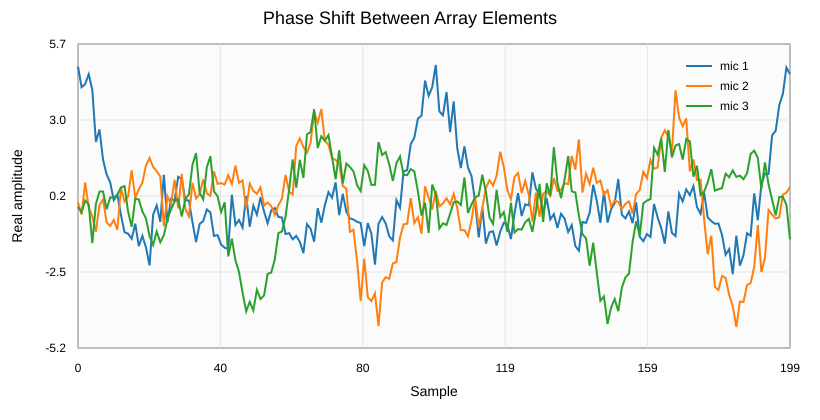

In [ ]:
# Phase shift between first 3 elements of array
plt.plot(np.asarray(X[0, :]).squeeze().real[0:200], label="mic 1")
plt.plot(np.asarray(X[1, :]).squeeze().real[0:200], label="mic 2")
plt.plot(np.asarray(X[2, :]).squeeze().real[0:200], label="mic 3")
plt.xlabel("Sample")
plt.ylabel("Real amplitude")
plt.title("Phase Shift Between First 3 Array Elements")
plt.legend()
plt.show()


In [6]:
# LCMV weights
soi1_theta = 15 / 180 * np.pi  # convert to radians
soi2_theta = 60 / 180 * np.pi

R_inv = np.linalg.pinv(np.cov(X))  # 8 x 8

s1 = np.exp(2j * np.pi * d * np.arange(Nr) * np.sin(soi1_theta)).reshape(-1, 1)  # 8 x 1
s2 = np.exp(2j * np.pi * d * np.arange(Nr) * np.sin(soi2_theta)).reshape(-1, 1)  # 8 x 1

C = np.concatenate((s1, s2), axis=1)  # 8 x 2
f = np.ones(2).reshape(-1, 1)         # 2 x 1

w = R_inv @ C @ np.linalg.pinv(C.conj().T @ R_inv @ C) @ f  # output is 8 x 1

print("C shape:", C.shape)
print("f shape:", f.shape)
print("w shape:", w.shape)
print(f"soi1 response: {(w.conj().T @ s1).item().real:+.4f}{(w.conj().T @ s1).item().imag:+.4f}j")
print(f"soi2 response: {(w.conj().T @ s2).item().real:+.4f}{(w.conj().T @ s2).item().imag:+.4f}j")


C shape: (8, 2)
f shape: (2, 1)
w shape: (8, 1)
soi1 response: +1.0000+0.0000j
soi2 response: +1.0000+0.0000j


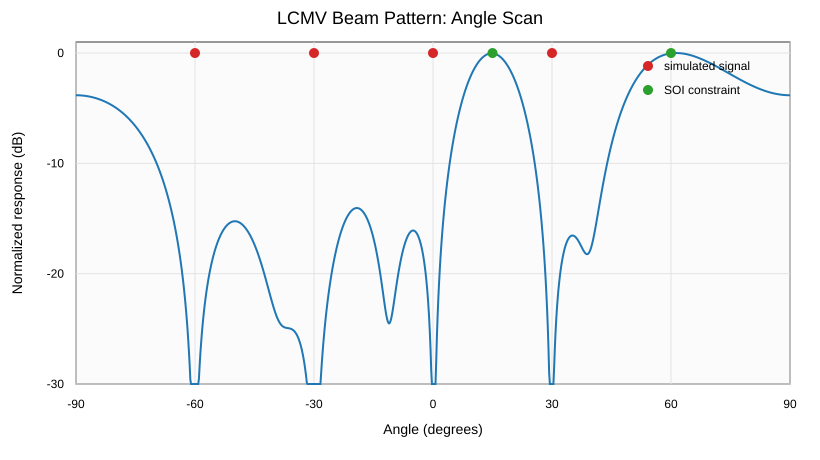

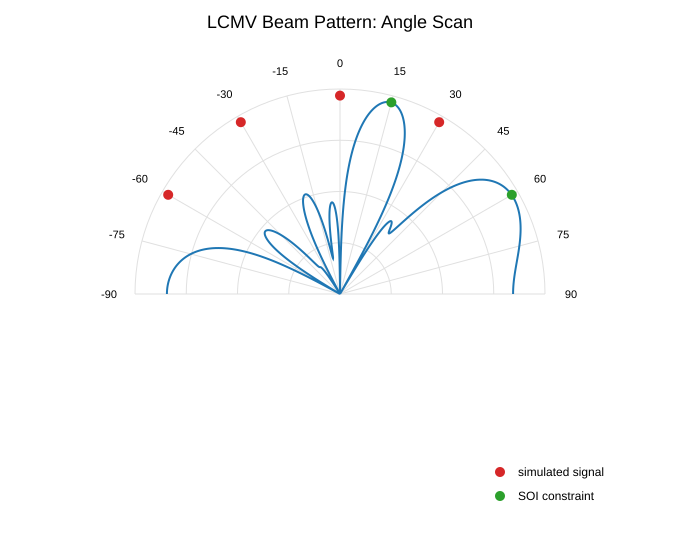

In [ ]:
# Plot beam pattern by scanning angles
theta_scan = np.linspace(-1 * np.pi / 2, np.pi / 2, 1000)
theta_scan_deg = theta_scan * 180 / np.pi

s = np.exp(2j * np.pi * d * np.arange(Nr).reshape(-1, 1) * np.sin(theta_scan))
response = np.abs(w.conj().T @ s).squeeze()
response_db = 20 * np.log10(response)
response_db -= np.max(response_db)

# Cartesian plot
plt.plot(theta_scan_deg, response_db)
plt.plot(theta1 * 180 / np.pi, 0, "or", label="simulated signal")
plt.plot(theta2 * 180 / np.pi, 0, "or")
plt.plot(theta3 * 180 / np.pi, 0, "or")
plt.plot(theta4 * 180 / np.pi, 0, "or")
plt.plot(soi1_theta * 180 / np.pi, 0, "og", label="SOI constraint")
plt.plot(soi2_theta * 180 / np.pi, 0, "og")
plt.xlabel("Angle (degrees)")
plt.ylabel("Normalized response (dB)")
plt.title("LCMV Beam Pattern: Angle Scan")
plt.xlim(-90, 90)
plt.ylim(-30, 1)
plt.legend(loc="lower right")
plt.show()

# Polar plot
fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
ax.plot(theta_scan, response_db)
ax.plot([theta1], [0], "or", label="simulated signal")
ax.plot([theta2], [0], "or")
ax.plot([theta3], [0], "or")
ax.plot([theta4], [0], "or")
ax.plot([soi1_theta], [0], "og", label="SOI constraint")
ax.plot([soi2_theta], [0], "og")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_thetagrids(np.arange(-90, 105, 15))
ax.set_rlabel_position(55)
ax.set_thetamin(-90)
ax.set_thetamax(90)
ax.set_ylim([-30, 1])
ax.set_title("LCMV Beam Pattern: Angle Scan")
ax.legend(loc="upper right")
plt.show()


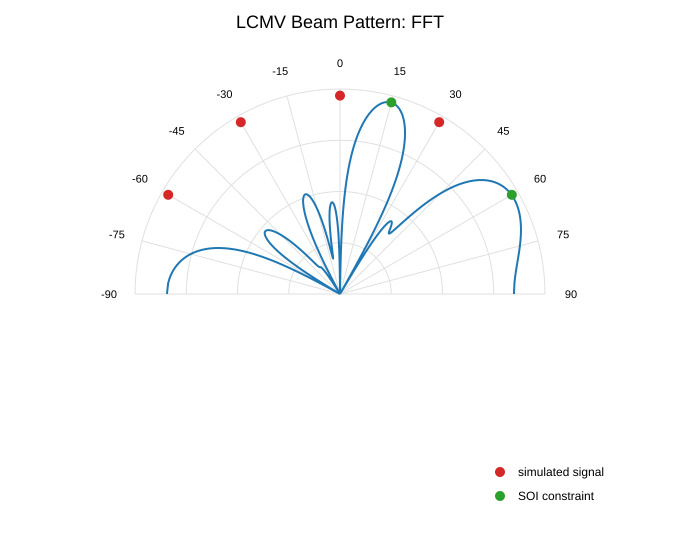

In [8]:
# Plot beam pattern with FFT
w = w.squeeze()
N_fft = 1024

w_padded = np.concatenate((w, np.zeros(N_fft - Nr)))
w_fft_dB = 10 * np.log10(np.abs(np.fft.fftshift(np.fft.fft(w_padded))) ** 2)
w_fft_dB -= np.max(w_fft_dB)

theta_bins = np.arcsin(np.linspace(-1, 1, N_fft))

fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
ax.plot(theta_bins, w_fft_dB)  # polar plots use radians

ax.plot([theta1], [0], "or", label="simulated signal")
ax.plot([theta2], [0], "or")
ax.plot([theta3], [0], "or")
ax.plot([theta4], [0], "or")
ax.plot([soi1_theta], [0], "og", label="SOI constraint")
ax.plot([soi2_theta], [0], "og")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_thetagrids(np.arange(-90, 105, 15))
ax.set_rlabel_position(55)
ax.set_thetamin(-90)
ax.set_thetamax(90)
ax.set_ylim([-30, 1])
ax.set_title("LCMV Beam Pattern: FFT")
ax.legend(loc="upper right")
plt.show()
